In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('weight_experiment_df.csv')

In [3]:
df.weight_param.value_counts()

weight_param
0.5     4500
2.0     3000
6.0     3000
10.0    3000
Name: count, dtype: int64

In [4]:
def tail_share(weights, tail_indices, p_init=1/3):
    W = sum(weights)
    W_tail = sum(weights[tail_indices:])
    return p_init * W_tail / W  # доля в общей популяции


print('Deepseek Chat')
print( tail_share([2, 2, 2, 2, 1, 1, 1] + [0.5] * 9, tail_indices=7), tail_share([2, 2, 2, 2, 1, 1, 1] + [0.5] * 9, tail_indices=7) / 0.33)
print( tail_share([2, 2, 2, 2, 1, 1, 1] + [2] * 9, tail_indices=7), tail_share([2, 2, 2, 2, 1, 1, 1] + [1] * 9, tail_indices=7) / 0.33 )
print( tail_share([2, 2, 2, 2, 1, 1, 1] + [6] * 9, tail_indices=7), tail_share([2, 2, 2, 2, 1, 1, 1] + [5] * 9, tail_indices=7) / 0.33)
print( tail_share([2, 2, 2, 2, 1, 1, 1] + [10] * 9, tail_indices=7), tail_share([2, 2, 2, 2, 1, 1, 1] + [10] * 9, tail_indices=7) / 0.33)


print('Reasoner')
print( tail_share([2, 2, 2, 2, 1, 1, 1] + [0.5] * 5, tail_indices=7) )
print( tail_share([2, 2, 2, 2, 1, 1, 1] + [2] * 5, tail_indices=7)  )
print( tail_share([2, 2, 2, 2, 1, 1, 1] + [6] * 5, tail_indices=7) )
print( tail_share([2, 2, 2, 2, 1, 1, 1] + [10] * 5, tail_indices=7) )


Deepseek Chat
0.0967741935483871 0.29325513196480935
0.20689655172413793 0.45454545454545453
0.27692307692307694 0.8116883116883117
0.297029702970297 0.9000900090009
Reasoner
0.06172839506172839
0.15873015873015872
0.24390243902439024
0.27322404371584696


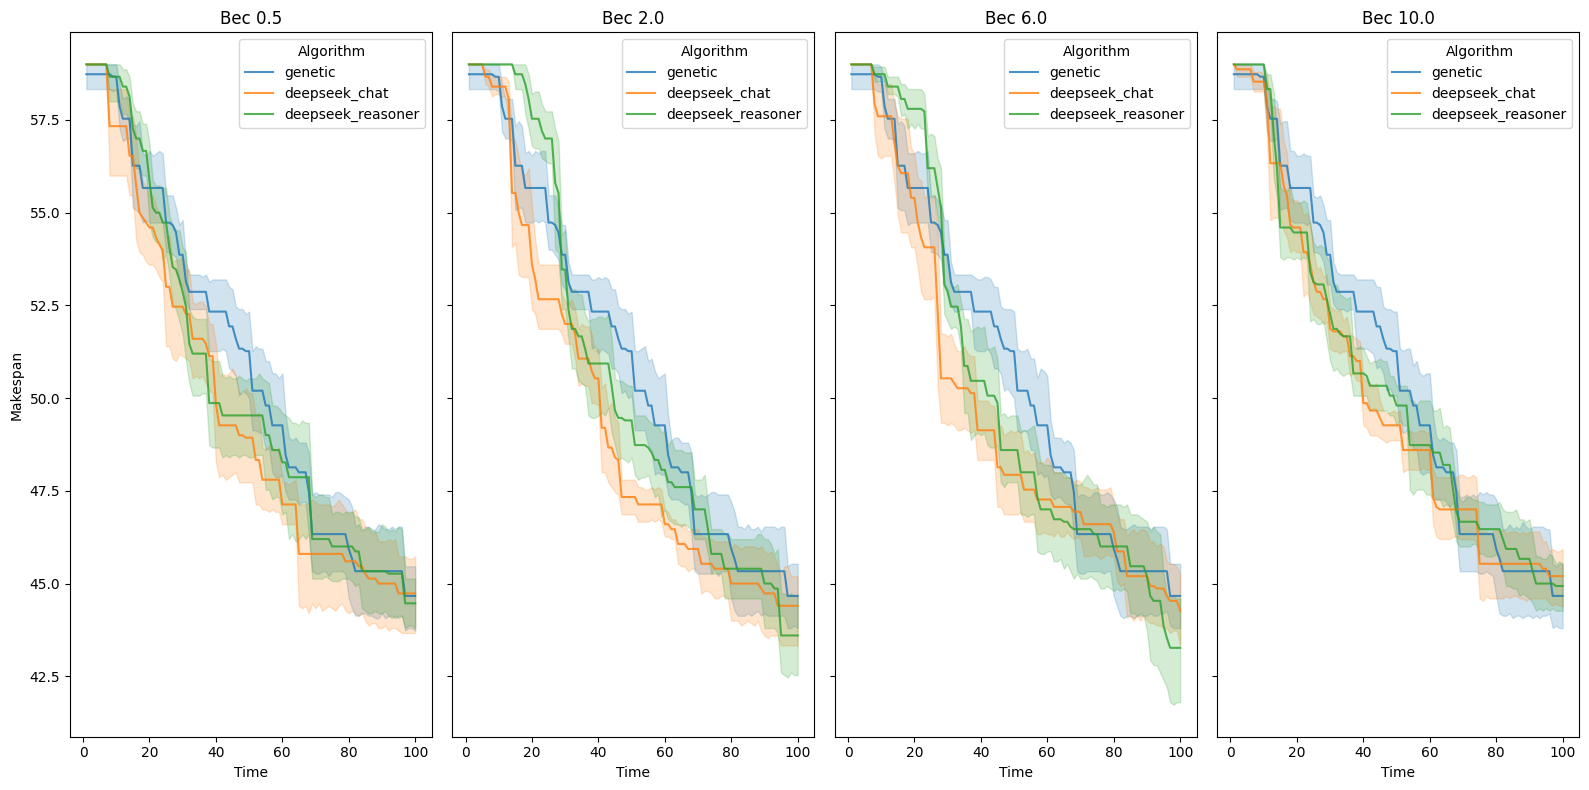

In [21]:
_, axes = plt.subplots(*(1,4), figsize=(16,8), sharey=True)


df = pd.read_csv('weight_experiment_df.csv')

sns.lineplot(df.query('weight_param == 0.5 or Algorithm == "genetic"'),
              x='Time', y='Makespan', hue='Algorithm', 
              estimator='mean', alpha=0.8, ax = axes[0])


sns.lineplot(df.query('weight_param == 2.0 or Algorithm == "genetic"'),
              x='Time', y='Makespan', hue='Algorithm', 
              estimator='mean', alpha=0.8, ax = axes[1])


sns.lineplot(df.query('weight_param == 6.0 or Algorithm == "genetic"'),
              x='Time', y='Makespan', hue='Algorithm', 
            estimator='mean', alpha=0.8, ax = axes[2])


sns.lineplot(df.query('weight_param == 10.0 or Algorithm == "genetic"'),
              x='Time', y='Makespan', hue='Algorithm', 
             estimator='mean', alpha=0.8, ax = axes[3])


for ax, w in zip(axes, (0.5, 2.0, 6.0, 10.0)):
    ax.set_title(f'Вес {w}')

plt.tight_layout()
    

#  units='run', estimator=None

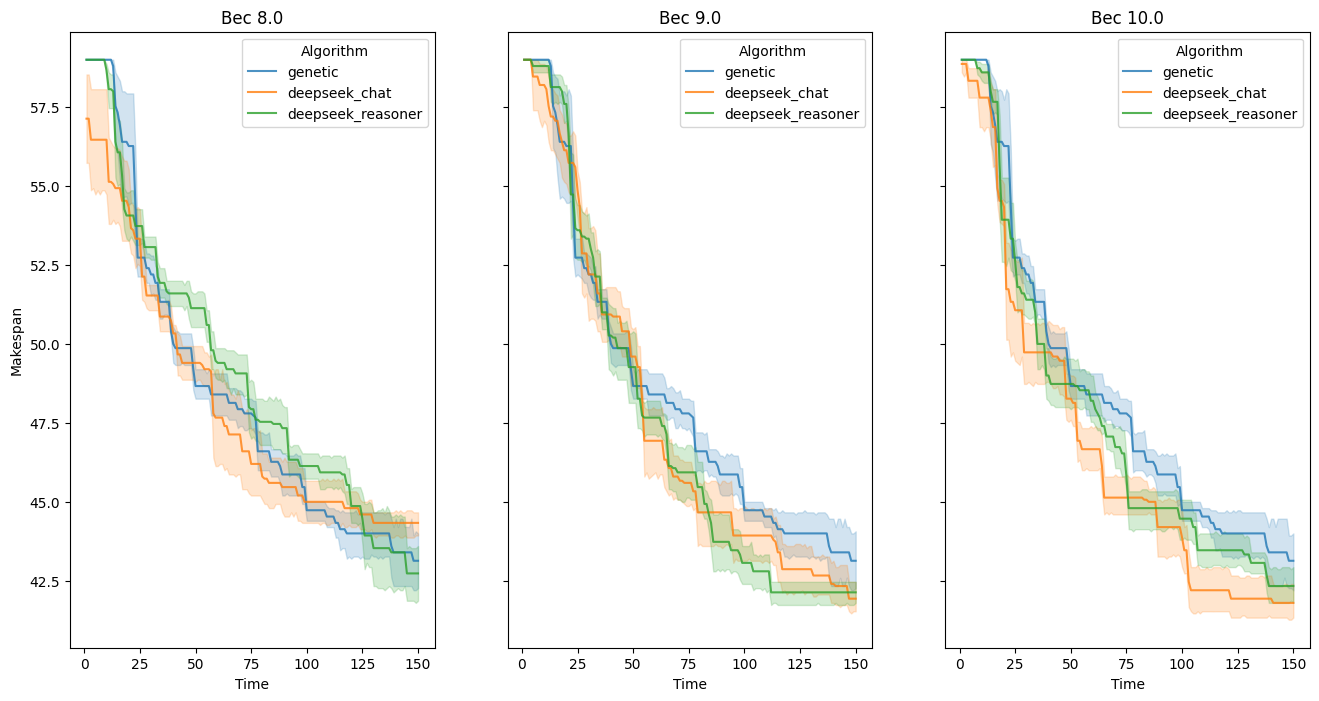

In [20]:
df = pd.read_csv('weight_experiment2_df.csv')

_, axes = plt.subplots(*(1,3), figsize=(16,8), sharey=True)



sns.lineplot(df.query('weight_param == 8.0 or Algorithm == "genetic" '),
              x='Time', y='Makespan', hue='Algorithm', 
              estimator='mean', alpha=0.8, ax = axes[0])


sns.lineplot(df.query('weight_param == 9.0 or Algorithm == "genetic" '),
              x='Time', y='Makespan', hue='Algorithm', 
              estimator='mean', alpha=0.8, ax = axes[1])


sns.lineplot(df.query('weight_param == 10.0 or Algorithm == "genetic" '),
              x='Time', y='Makespan', hue='Algorithm', 
            estimator='mean', alpha=0.8, ax = axes[2])


for ax, w in zip(axes, (8.0, 9.0, 10.0)):
    ax.set_title(f'Вес {w}')


# sns.lineplot(df.query('weight_param == 10.0'),
#               x='Time', y='Makespan', hue='Algorithm', 
#              estimator='mean', alpha=0.8, ax = axes[3])

#  units='run', estimator=None

In [9]:
df.groupby('Algorithm').Makespan.min()

Algorithm
deepseek_chat        41.0
deepseek_reasoner    40.0
genetic              41.0
Name: Makespan, dtype: float64

# Эксперимент с % эвристик в популяции

<Axes: xlabel='Time', ylabel='Makespan'>

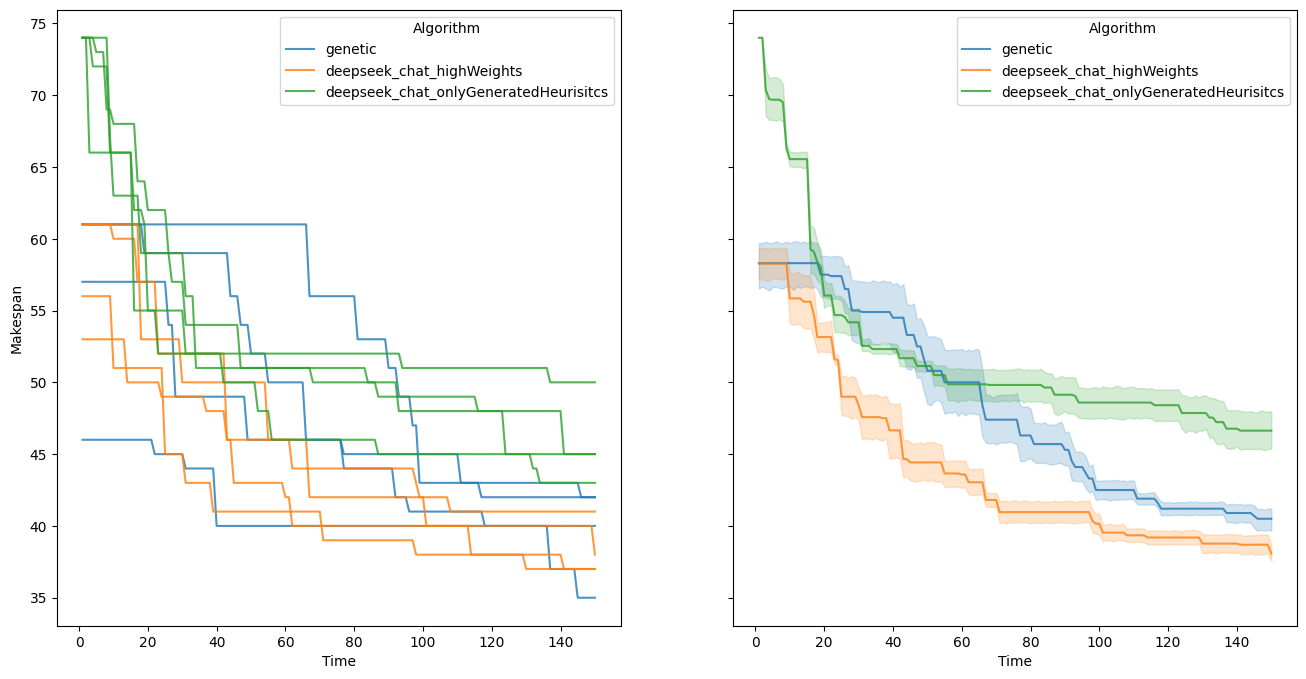

In [27]:
df = pd.read_csv('structure_experiment_Deepseek.csv')


_, axes = plt.subplots(*(1,2), figsize=(16,8), sharey=True)


axes = axes.flatten()

sns.lineplot( data = df,
              x='Time', y='Makespan', hue='Algorithm', 
              units='run',
              estimator=None, alpha=0.8, ax = axes[0])


sns.lineplot( data = df,
              x='Time', y='Makespan', hue='Algorithm', 
              estimator='mean', alpha=0.8, ax = axes[1])


<Axes: xlabel='Time', ylabel='Makespan'>

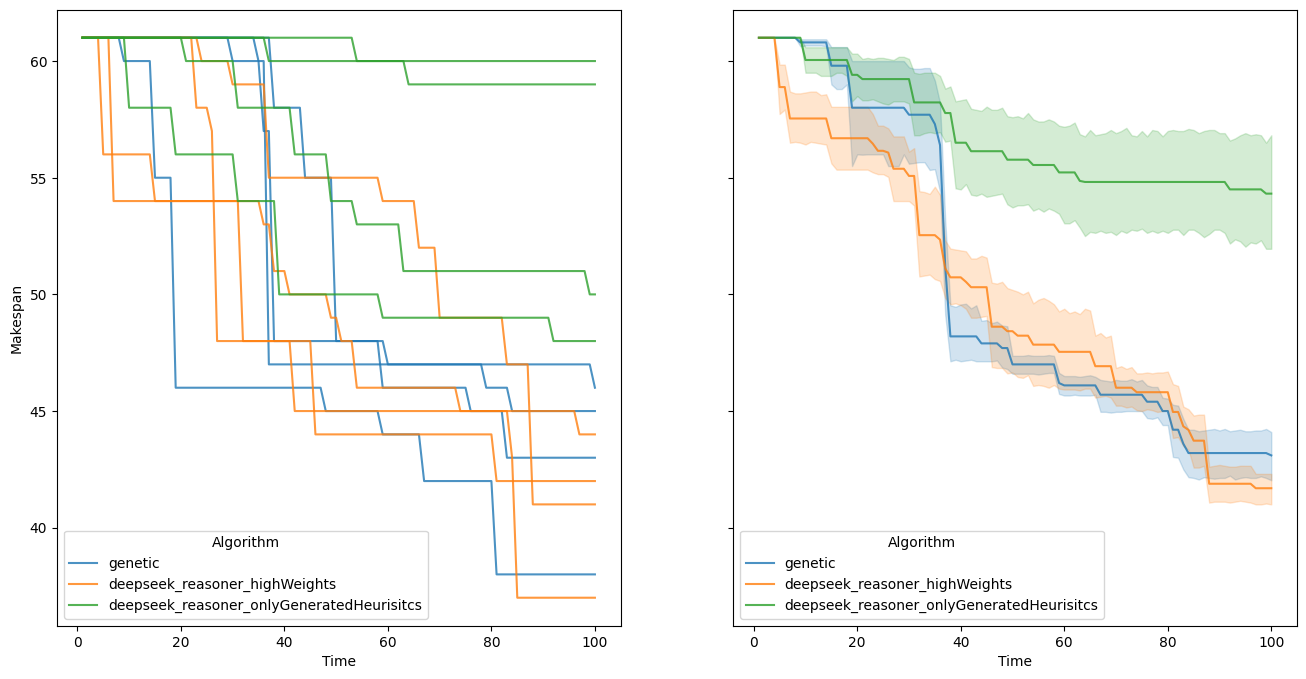

In [14]:
df = pd.read_csv('structure_experiment_DRChat.csv')


_, axes = plt.subplots(*(1,2), figsize=(16,8), sharey=True)



sns.lineplot( data = df,
              x='Time', y='Makespan', hue='Algorithm', 
              units='run',
              estimator=None, alpha=0.8, ax = axes[0])


sns.lineplot( data = df,
              x='Time', y='Makespan', hue='Algorithm', 
              estimator='mean', alpha=0.8, ax = axes[1])


<Axes: xlabel='Time', ylabel='Makespan'>

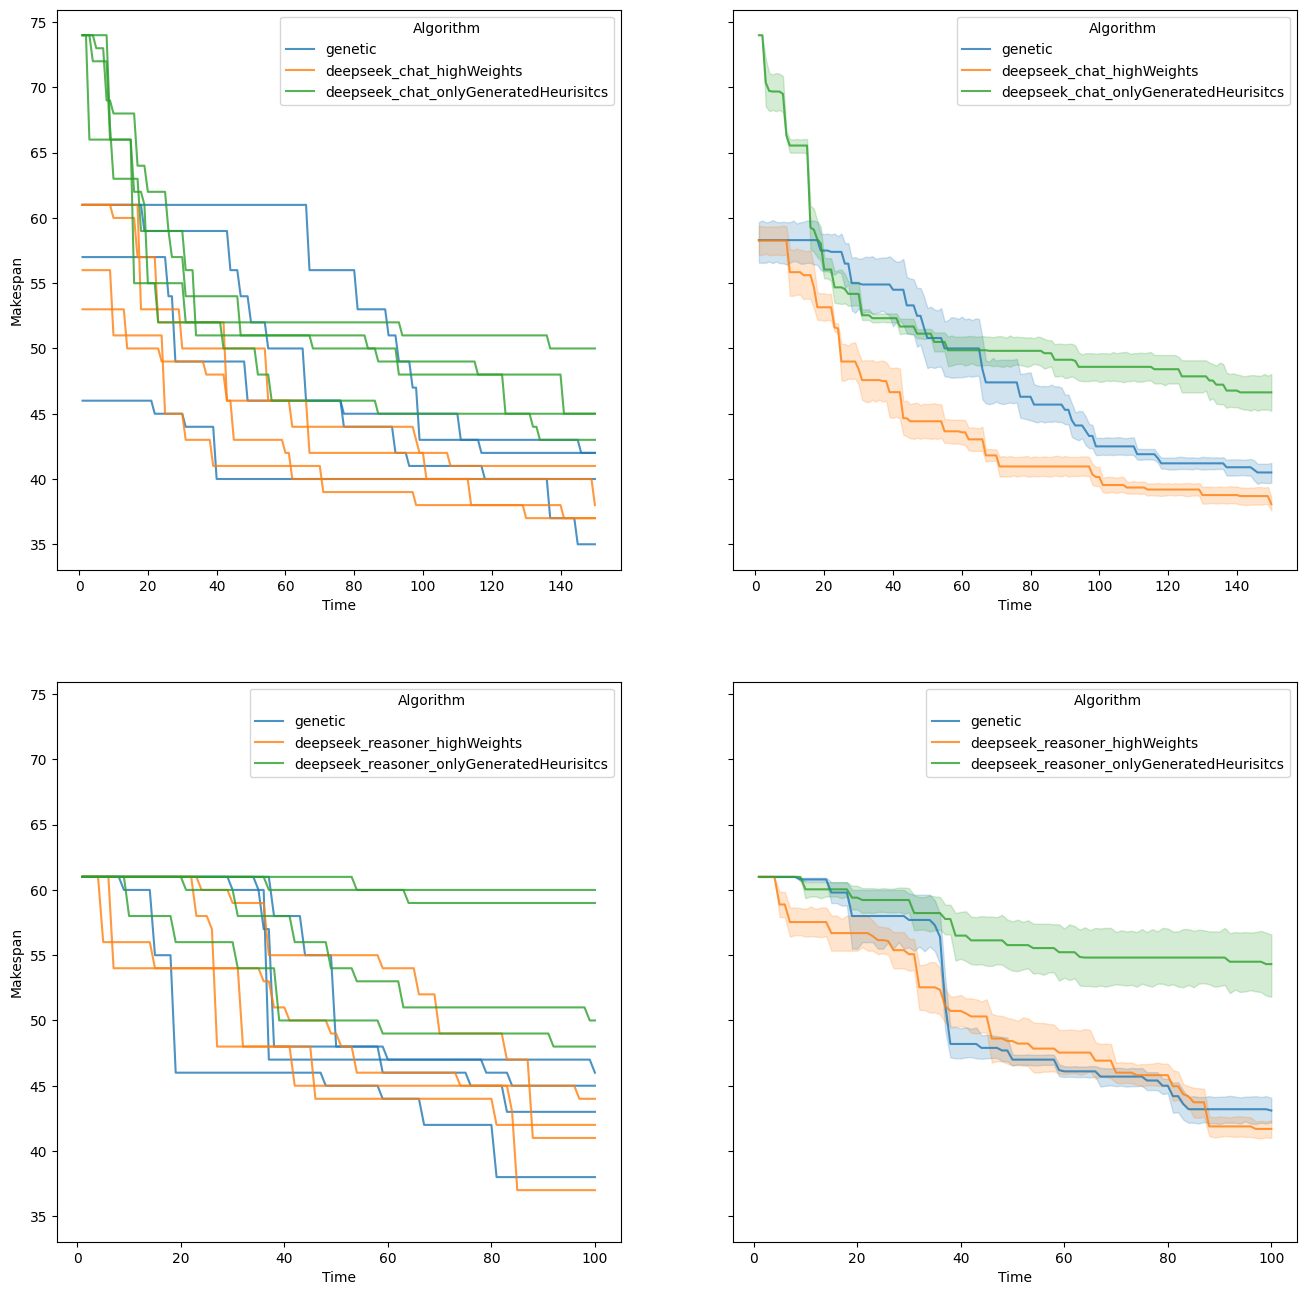

In [28]:
df = pd.read_csv('structure_experiment_Deepseek.csv')


_, axes = plt.subplots(*(2,2), figsize=(16,16), sharey=True)


axes = axes.flatten()

sns.lineplot( data = df,
              x='Time', y='Makespan', hue='Algorithm', 
              units='run',
              estimator=None, alpha=0.8, ax = axes[0])


sns.lineplot( data = df,
              x='Time', y='Makespan', hue='Algorithm', 
              estimator='mean', alpha=0.8, ax = axes[1])

df = pd.read_csv('structure_experiment_DRChat.csv')



sns.lineplot( data = df,
              x='Time', y='Makespan', hue='Algorithm', 
              units='run',
              estimator=None, alpha=0.8, ax = axes[2])


sns.lineplot( data = df,
              x='Time', y='Makespan', hue='Algorithm', 
              estimator='mean', alpha=0.8, ax = axes[3])

